# Inverse-CDF Comparisons: Learned vs Custom-Cut

This notebook builds **two 2x2 inverse cumulative (survival CDF) comparisons** for `epeak`, `t90`, `fluence`, and `pflux`:

1. **Learned distribution**: simulation with minimal cuts (keep only `T90 < 2 s` and broad `Epeak` range).
2. **Custom-cut observed vs simulated**: apply user-defined cuts to both observed catalogue and simulation.

It assumes you already have a converged chain (`emcee.h5`).

In [29]:
%load_ext autoreload
%autoreload 2

import notebook_setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import emcee

from src import init, posteriors

plt.style.use('../configurations/style.mplstyle')

datafiles = Path('../datafiles')

params = {
    'alpha': -0.67,
    'beta_s': -2.59,
    'n': 2,
    'theta_c': 3.4,
    'theta_v_max': 10,
    'z_model': 'fiducial_Hrad_A1.0',
}

default_params, default_interpolator, data_dict = init.initialize_simulation(datafiles, params)

# Update this path if your converged chain is elsewhere.
#backend_path = Path('../Output_files/structured_jet/Grinta/emcee.h5')
backend_path = Path("/mnt/c/Users/Ludovico/Downloads/MAGGPY/Tutorials_ACME/Output_files/tutorial2_structured/emcee.h5")
backend = emcee.backends.HDFBackend(backend_path)

DISCARD = 1000

print(f'Using backend: {backend_path}')
print(f'Chain shape: {backend.shape}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using redshift model: samples_fiducial_Hrad_A1.0_BNSs_0.dat with 359079 BNSs.
Computed total merger rate: 360832.5 yr^-1 (local R_0 = 112.0 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Using backend: /mnt/c/Users/Ludovico/Downloads/MAGGPY/Tutorials_ACME/Output_files/tutorial2_structured/emcee.h5
Chain shape: (20, 7)


In [30]:
def inverse_cdf(arr):
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]
    arr = arr[arr > 0]
    if arr.size == 0:
        return np.array([]), np.array([])
    x = np.sort(arr)
    y = np.arange(x.size, 0, -1) / x.size
    return x, y

def plot_inverse_cdf_panel(obs_data, sim_data, title, cuts=None):
    fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharey='row')
    fontsize_label = 15
    fontsize_ticks = 12

    specs = [
        ('epeak', 'Peak Energy (keV)', True),
        ('t90', r'$T_{90}$ (s)', False),
        ('fluence', r'Fluence (erg cm$^{-2}$)', True),
        ('pflux', r'Peak Flux (ph cm$^{-2}$ s$^{-1}$)', True),
    ]

    for ax, (key, xlabel, use_logx) in zip(axes.ravel(), specs):
        xo, yo = inverse_cdf(obs_data[key])
        xs, ys = inverse_cdf(sim_data[key])

        if xo.size > 0:
            if use_logx:
                ax.loglog(xo, yo, 'k', lw=2.2, label='Observed')
            else:
                ax.semilogy(xo, yo, 'k', lw=2.2, label='Observed')

        if xs.size > 0:
            if use_logx:
                ax.loglog(xs, ys, color='crimson', lw=2, alpha=0.9, label='Simulated')
            else:
                ax.semilogy(xs, ys, color='crimson', lw=2, alpha=0.9, label='Simulated')

        if cuts is not None and key == 'epeak':
            if 'EP_LIM_LOWER' in cuts:
                ax.axvline(cuts['EP_LIM_LOWER'], color='gray', ls='--', lw=1.5)
            if 'EP_LIM_UPPER' in cuts:
                ax.axvline(cuts['EP_LIM_UPPER'], color='gray', ls='--', lw=1.5)

        if cuts is not None and key == 'pflux' and 'F_LIM' in cuts and cuts['F_LIM'] > 0:
            ax.axvline(cuts['F_LIM'], color='gray', ls='--', lw=1.5)

        if cuts is not None and key == 't90' and 'T90_LIM' in cuts:
            ax.axvline(cuts['T90_LIM'], color='gray', ls='--', lw=1.5)

        ax.set_xlabel(xlabel, fontsize=fontsize_label)
        ax.tick_params(axis='both', which='major', labelsize=fontsize_ticks)

    axes[0, 0].set_ylabel('Inverse CDF', fontsize=fontsize_label)
    axes[1, 0].set_ylabel('Inverse CDF', fontsize=fontsize_label)
    axes[0, 0].legend(loc='best', fontsize=11)
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    return fig

In [31]:
catalogue_data = pd.read_csv(datafiles / 'burst_catalog.dat')

# Common positive-value cleaning for each variable.
obs_base = {
    'pflux': catalogue_data['FLUX_BATSE_64'].dropna().values,
    't90': catalogue_data['T90'].dropna().values,
    'fluence': catalogue_data['FLUENCE_BATSE'].dropna().values,
    'epeak': catalogue_data['PFLX_COMP_EPEAK'].dropna().values,
}

obs_base = {k: v[np.isfinite(v) & (v > 0)] for k, v in obs_base.items()}

# Learned comparison: only enforce short-GRB duration threshold on the observed sample.
obs_learned = {
    'pflux': obs_base['pflux'],
    'epeak': obs_base['epeak'],
    'fluence': obs_base['fluence'],
    't90': obs_base['t90'][obs_base['t90'] < 2.0],
}

# Custom observed cuts (edit as needed).
CUSTOM_LIMITS = {
    'F_LIM': 4.0,
    'T90_LIM': 2.0,
    'EP_LIM_LOWER': 50.0,
    'EP_LIM_UPPER': 10_000.0,
}

obs_custom = {
    'pflux': obs_base['pflux'][obs_base['pflux'] > CUSTOM_LIMITS['F_LIM']],
    't90': obs_base['t90'][obs_base['t90'] < CUSTOM_LIMITS['T90_LIM']],
    'epeak': obs_base['epeak'][(obs_base['epeak'] > CUSTOM_LIMITS['EP_LIM_LOWER']) & (obs_base['epeak'] < CUSTOM_LIMITS['EP_LIM_UPPER'])],
    'fluence': obs_base['fluence'],
}

print('Observed sample sizes (learned):', {k: len(v) for k, v in obs_learned.items()})
print('Observed sample sizes (custom):', {k: len(v) for k, v in obs_custom.items()})

Observed sample sizes (learned): {'pflux': 705, 'epeak': 506, 'fluence': 705, 't90': 705}
Observed sample sizes (custom): {'pflux': 325, 't90': 705, 'epeak': 498, 'fluence': 705}


In [32]:
# Best-fit sample from converged chain.
flat_chain = backend.get_chain(discard=DISCARD, flat=True)
flat_logprob = backend.get_log_prob(discard=DISCARD, flat=True)
best_idx = np.argmax(flat_logprob)
thetas_best = flat_chain[best_idx]
print('Best-fit parameters:', thetas_best)

# Learned simulation limits: no flux cut, very broad Epeak cuts, keep T90<2s.
LEARNED_LIMITS = {
    'F_LIM': 0.0,
    'T90_LIM': 2.0,
    'EP_LIM_LOWER': 1.0,
    'EP_LIM_UPPER': 1e6,
}

sim_learned = posteriors.extract_samples_and_calculate_cdfs(
    sampler=backend,
    default_params=default_params,
    default_interpolator=default_interpolator,
    discard=DISCARD,
    flatten=True,
    choices=20,
    limits=LEARNED_LIMITS,
    years_of_data_simulated=10,
    use_best=True,
)

sim_custom = posteriors.extract_samples_and_calculate_cdfs(
    sampler=backend,
    default_params=default_params,
    default_interpolator=default_interpolator,
    discard=DISCARD,
    flatten=True,
    choices=20,
    limits=CUSTOM_LIMITS,
    years_of_data_simulated=10,
    use_best=True,
)

print('Simulated sample sizes (learned):', {k: len(sim_learned[k]) for k in ['pflux', 't90', 'epeak', 'fluence']})
print('Simulated sample sizes (custom):', {k: len(sim_custom[k]) for k in ['pflux', 't90', 'epeak', 'fluence']})

Best-fit parameters: [ 3.0935291  -0.92543351  3.45922919  0.37639773 -0.61750593  0.73583619
  0.65625465]
Best samples are used for PPC: [ 3.0935291  -0.92543351  3.45922919  0.37639773 -0.61750593  0.73583619
  0.65625465]
Best samples are used for PPC: [ 3.0935291  -0.92543351  3.45922919  0.37639773 -0.61750593  0.73583619
  0.65625465]
Simulated sample sizes (learned): {'pflux': 5598, 't90': 5598, 'epeak': 5598, 'fluence': 5598}
Simulated sample sizes (custom): {'pflux': 210, 't90': 210, 'epeak': 210, 'fluence': 210}


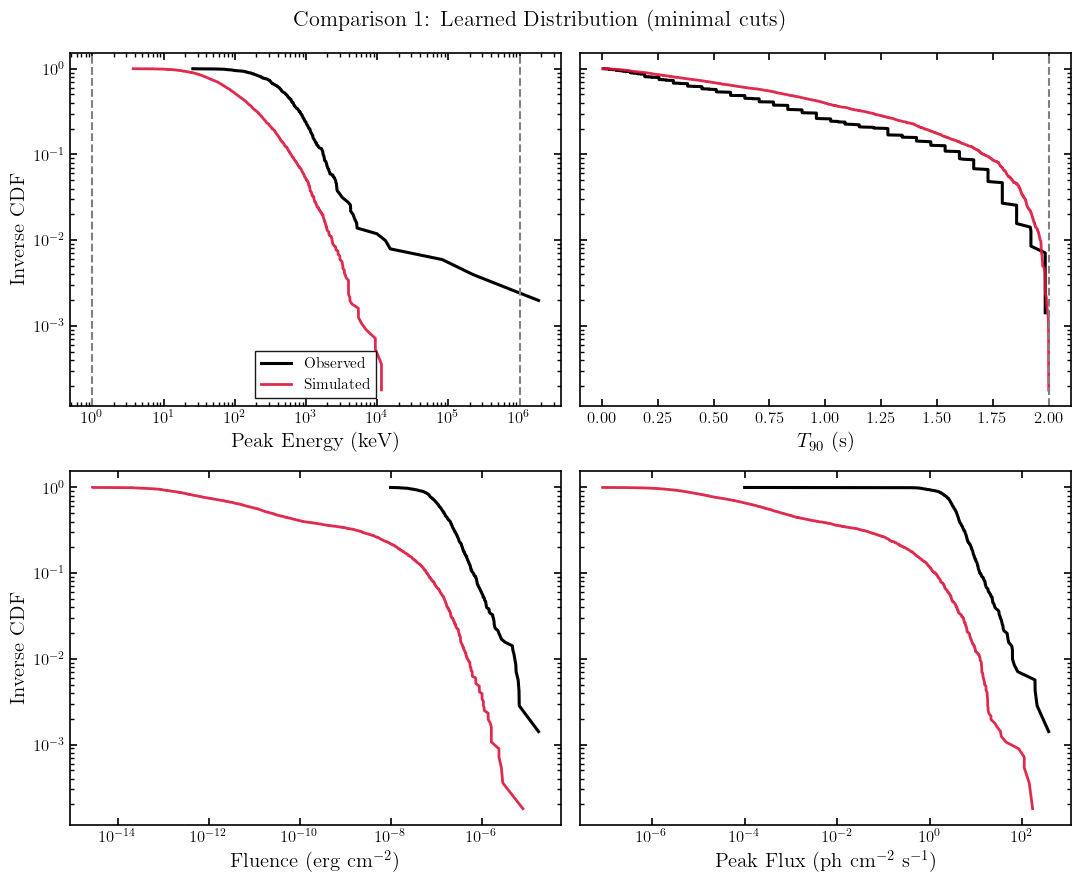

In [33]:
fig1 = plot_inverse_cdf_panel(
    obs_data=obs_learned,
    sim_data=sim_learned,
    title='Comparison 1: Learned Distribution (minimal cuts)',
    cuts=LEARNED_LIMITS,
)
fig1.savefig('inverse_cdf_learned_minimal_cuts.pdf', dpi=400, bbox_inches='tight')
plt.show()

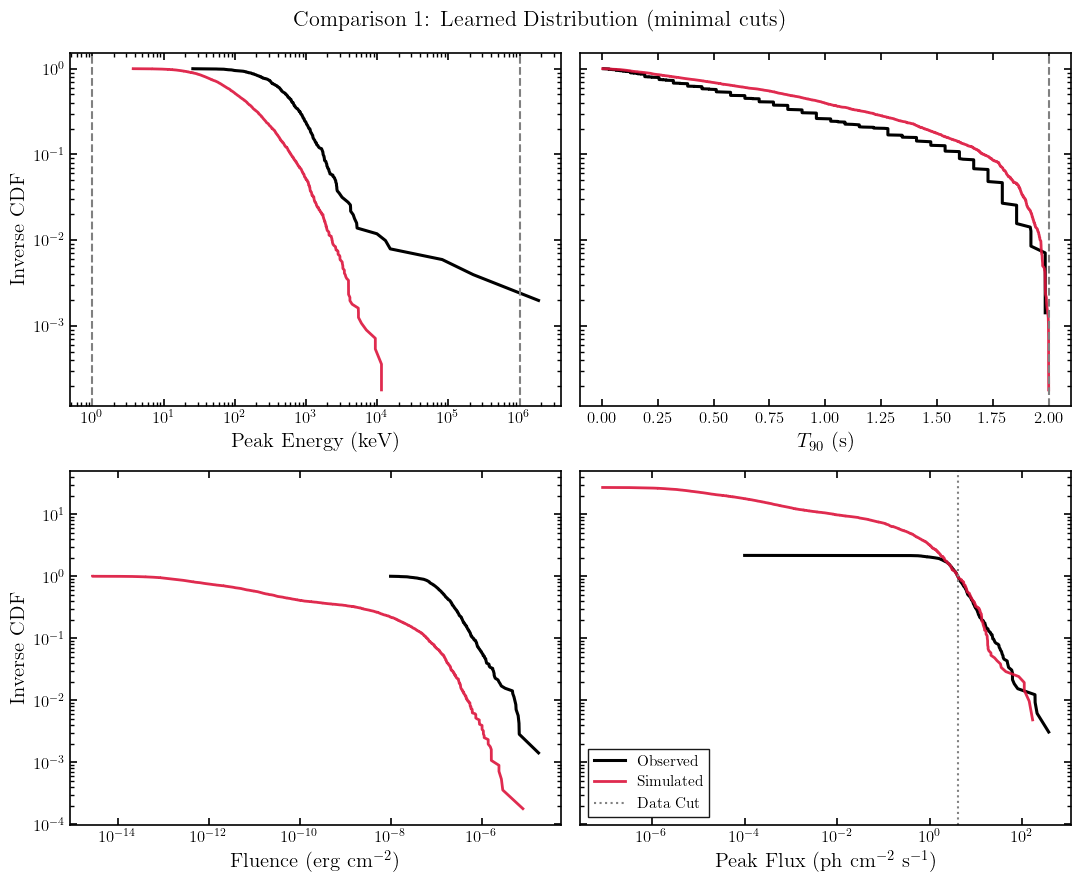

In [34]:
def plot_inverse_cdf_panel(obs_data, sim_data, title, cuts=None, normalize_pflux_at=None):
    fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharey='row')
    fontsize_label = 15
    fontsize_ticks = 12

    specs = [
        ('epeak', 'Peak Energy (keV)', True),
        ('t90', r'$T_{90}$ (s)', False),
        ('fluence', r'Fluence (erg cm$^{-2}$)', True),
        ('pflux', r'Peak Flux (ph cm$^{-2}$ s$^{-1}$)', True),
    ]

    for ax, (key, xlabel, use_logx) in zip(axes.ravel(), specs):
        xo, yo = inverse_cdf(obs_data[key])
        xs, ys = inverse_cdf(sim_data[key])

        # Apply normalization if specified and we are on the pflux panel
        if key == 'pflux' and normalize_pflux_at is not None:
            if xo.size > 0:
                idx_o = np.searchsorted(xo, normalize_pflux_at)
                if idx_o < len(yo):
                    yo = yo / yo[idx_o]
            if xs.size > 0:
                idx_s = np.searchsorted(xs, normalize_pflux_at)
                if idx_s < len(ys):
                    ys = ys / ys[idx_s]

        if xo.size > 0:
            if use_logx:
                ax.loglog(xo, yo, 'k', lw=2.2, label='Observed')
            else:
                ax.semilogy(xo, yo, 'k', lw=2.2, label='Observed')

        if xs.size > 0:
            if use_logx:
                ax.loglog(xs, ys, color='crimson', lw=2, alpha=0.9, label='Simulated')
            else:
                ax.semilogy(xs, ys, color='crimson', lw=2, alpha=0.9, label='Simulated')

        if cuts is not None and key == 'epeak':
            if 'EP_LIM_LOWER' in cuts:
                ax.axvline(cuts['EP_LIM_LOWER'], color='gray', ls='--', lw=1.5)
            if 'EP_LIM_UPPER' in cuts:
                ax.axvline(cuts['EP_LIM_UPPER'], color='gray', ls='--', lw=1.5)

        if cuts is not None and key == 'pflux' and 'F_LIM' in cuts and cuts['F_LIM'] > 0:
            ax.axvline(cuts['F_LIM'], color='gray', ls='--', lw=1.5)
        # Also plot the normalization line if provided
        elif normalize_pflux_at is not None and key == 'pflux':
            ax.axvline(normalize_pflux_at, color='gray', ls=':', lw=1.5, label=f'Data Cut')

        if cuts is not None and key == 't90' and 'T90_LIM' in cuts:
            ax.axvline(cuts['T90_LIM'], color='gray', ls='--', lw=1.5)

        ax.set_xlabel(xlabel, fontsize=fontsize_label)
        ax.tick_params(axis='both', which='major', labelsize=fontsize_ticks)

        # Optional: update the ylabel if normalized
        ylabel = 'Normalized Inverse CDF' if (key == 'pflux' and normalize_pflux_at is not None) else 'Inverse CDF'
        if ax in [axes[0, 0], axes[1, 0]]:
            ax.set_ylabel(ylabel, fontsize=fontsize_label)

    axes[1, 1].legend(loc='best', fontsize=11)
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    return fig

fig1 = plot_inverse_cdf_panel(
    obs_data=obs_learned,
    sim_data=sim_learned,
    title='Comparison 1: Learned Distribution (minimal cuts)',
    cuts=LEARNED_LIMITS,
    normalize_pflux_at=4.0  # <--- Setting the normalization threshold here
)
fig1.savefig('inverse_cdf_learned_minimal_cuts.pdf', dpi=400, bbox_inches='tight')
plt.show()

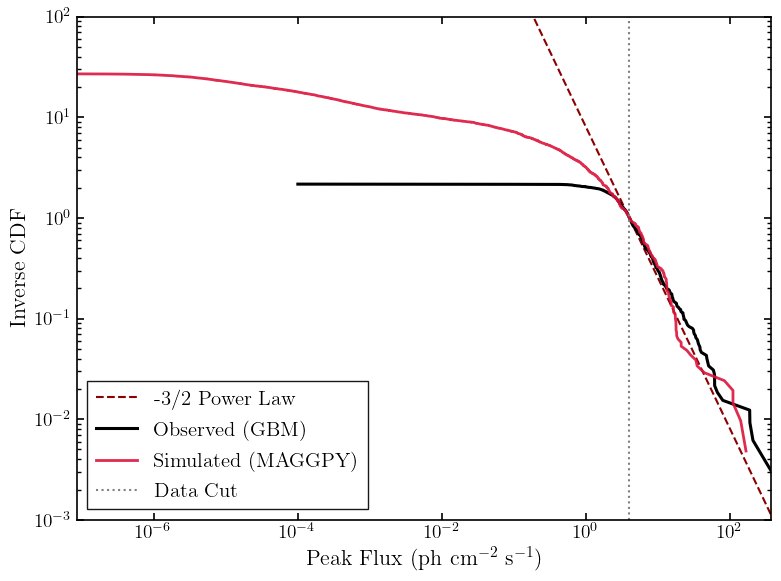

In [ ]:
#only plot pflux, also plot a -3/2 power law line (normalized to the data at the chosen flux cut) for reference. for reference

def plot_inverse_cdf_panel(obs_data, sim_data, title, cuts=None, normalize_pflux_at=None):
    fig, axes = plt.subplots(figsize=(8, 6))
    fontsize_label = 16
    fontsize_ticks = 14

    specs = [
        #('epeak', 'Peak Energy (keV)', True),
        #('t90', r'$T_{90}$ (s)', False),
        #('fluence', r'Fluence (erg cm$^{-2}$)', True),
        ('pflux', r'Peak Flux (ph cm$^{-2}$ s$^{-1}$)', True),
    ]

    ax = axes
    key = 'pflux'
    xlabel = r'Peak Flux (ph cm$^{-2}$ s$^{-1}$)'
    use_logx = True

    xo, yo = inverse_cdf(obs_data[key])
    xs, ys = inverse_cdf(sim_data[key])

    a = 1.0  # Normalization constant for the power-law reference line

    # Apply normalization if specified and we are on the pflux panel
    if key == 'pflux' and normalize_pflux_at is not None:

        if xo.size > 0:
            idx_o = np.searchsorted(xo, normalize_pflux_at)
            if idx_o < len(yo):
                yo = yo / yo[idx_o]
        if xs.size > 0:
            idx_s = np.searchsorted(xs, normalize_pflux_at)
            if idx_s < len(ys):
                ys = ys / ys[idx_s]
        # make a reference -3/2 power-law line for comparison that passes through the normalization point
        if xo.size > 0 and xs.size > 0:
            x_ref = np.logspace(np.log10(min(xo[0], xs[0])), np.log10(max(xo[-1], xs[-1])), 100)
            y_ref = a * (x_ref / normalize_pflux_at) ** (-3/2)
            if use_logx:
                ax.loglog(x_ref, y_ref, color='darkred', linestyle='--', label='-3/2 Power Law')
            else:
                ax.semilogy(x_ref, y_ref, color='darkred', linestyle='--', label='-3/2 Power Law')

    if xo.size > 0:
        if use_logx:
            ax.loglog(xo, yo, 'k', lw=2.2, label='Observed (GBM)')
        else:
            ax.semilogy(xo, yo, 'k', lw=2.2, label='Observed (GBM)')

    if xs.size > 0:
        if use_logx:
            ax.loglog(xs, ys, color='crimson', lw=2, alpha=0.9, label='Simulated (MAGGPY)')
        else:
            ax.semilogy(xs, ys, color='crimson', lw=2, alpha=0.9, label='Simulated (MAGGPY)')

    if cuts is not None and key == 'pflux' and 'F_LIM' in cuts and cuts['F_LIM'] > 0:
        ax.axvline(cuts['F_LIM'], color='gray', ls='--', lw=1.5)
    # Also plot the normalization line if provided
    elif normalize_pflux_at is not None and key == 'pflux':
        ax.axvline(normalize_pflux_at, color='gray', ls=':', lw=1.5, label=f'Data Cut')

    if cuts is not None and key == 't90' and 'T90_LIM' in cuts:
        ax.axvline(cuts['T90_LIM'], color='gray', ls='--', lw=1.5)

    ax.set_xlabel(xlabel, fontsize=fontsize_label)
    ax.tick_params(axis='both', which='major', labelsize=fontsize_ticks)

    # Optional: update the ylabel if normalized
    ylabel = 'Inverse CDF' if (key == 'pflux' and normalize_pflux_at is not None) else 'Inverse CDF'
    ax.set_ylabel(ylabel, fontsize=fontsize_label)
    ax.legend(loc='best', fontsize=15)
    ax.set_xlim(min(xo[0], xs[0]), max(xo[-1], xs[-1]))
    ax.set_ylim(1e-3, 100)
    #ticks should be bigger
    ax.tick_params(axis='both', which='major', labelsize=fontsize_ticks)
    plt.tight_layout()
    return fig

fig1 = plot_inverse_cdf_panel(
    obs_data=obs_learned,
    sim_data=sim_learned,
    title='Comparison 1: Learned Distribution (minimal cuts)',
    cuts=LEARNED_LIMITS,
    normalize_pflux_at=4.0  # <--- Setting the normalization threshold here
)
fig1.savefig('inverse_cdf_learned_minimal_cuts_pflux.pdf', dpi=400, bbox_inches='tight')
plt.show()

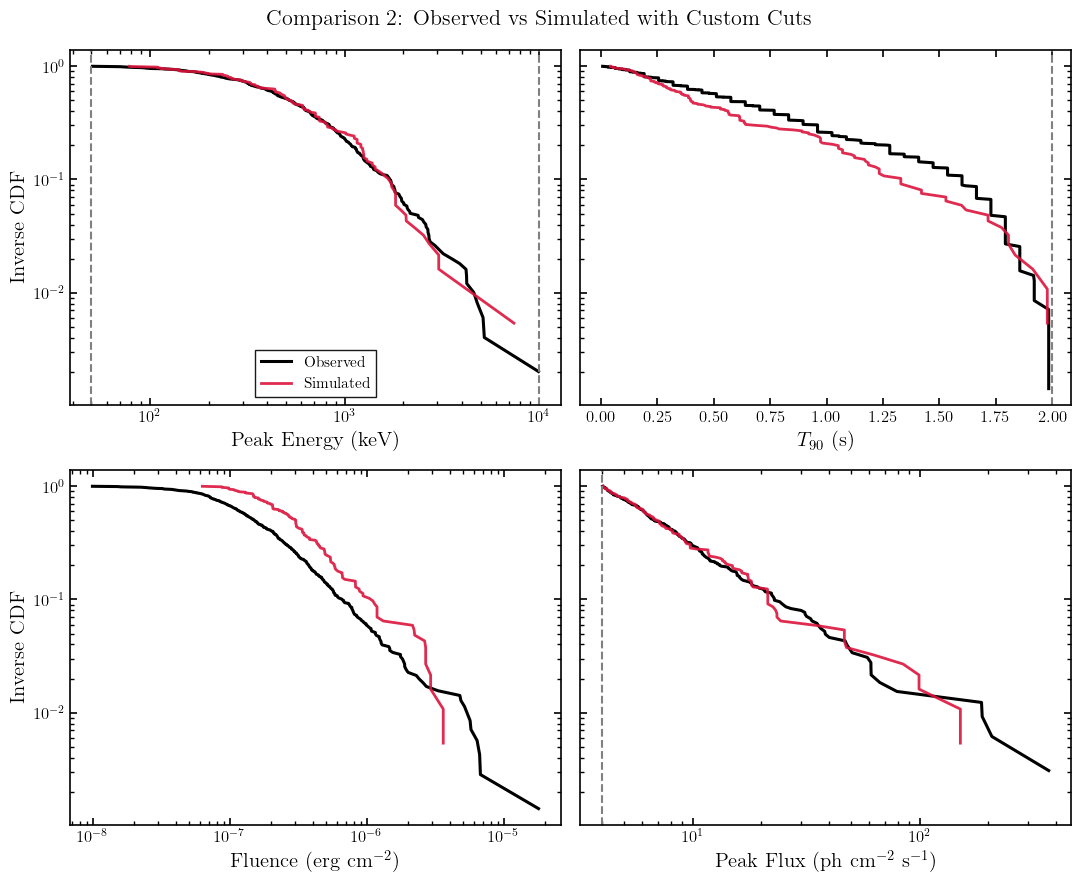

In [ ]:
fig2 = plot_inverse_cdf_panel(
    obs_data=obs_custom,
    sim_data=sim_custom,
    title='Comparison 2: Observed vs Simulated with Custom Cuts',
    cuts=CUSTOM_LIMITS,
)
fig2.savefig('inverse_cdf_observed_vs_sim_custom_cuts.pdf', dpi=400, bbox_inches='tight')
plt.show()